# PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) - DATASET TITANIC

## Mục tiêu phân tích
Trong notebook này, chúng ta sẽ thực hiện phân tích dữ liệu khám phá (EDA) toàn diện cho dataset Titanic bao gồm:

1. **Phân tích đơn biến (Univariate Analysis)**: Khám phá từng thuộc tính một cách độc lập
2. **Phân tích đa biến (Multivariate Analysis)**: Tìm hiểu mối quan hệ giữa các thuộc tính
3. **Phân tích mức độ phụ thuộc**: Đo lường và visualize mối quan hệ giữa các biến

Mục tiêu chính là hiểu được các yếu tố nào ảnh hưởng đến tỷ lệ sống sót của hành khách trên tàu Titanic.

In [13]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr

# Thiết lập
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
data_dir = '../../data/titanic/'
print("Đã import thành công các thư viện cần thiết!")

Đã import thành công các thư viện cần thiết!


## 1. ĐÓNG VÀ KHÁM PHÁ DỮ LIỆU BAN ĐẦU

In [14]:
# Đọc dữ liệu
train_df = pd.read_csv(f'{data_dir}train.csv')
test_df = pd.read_csv(f'{data_dir}test.csv')

print("THÔNG TIN CƠ BẢN VỀ DỮ LIỆU")
print("="*50)
print(f"Dữ liệu huấn luyện: {train_df.shape[0]} hành khách, {train_df.shape[1]} thuộc tính")
print(f"Dữ liệu kiểm tra: {test_df.shape[0]} hành khách, {test_df.shape[1]} thuộc tính")
print()

print("CÁC CỘT TRONG DATASET:")
print("="*30)
for i, col in enumerate(train_df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n5 HÀNG ĐẦU TIÊN CỦA DỮ LIỆU:")
train_df.head()

THÔNG TIN CƠ BẢN VỀ DỮ LIỆU
Dữ liệu huấn luyện: 891 hành khách, 12 thuộc tính
Dữ liệu kiểm tra: 418 hành khách, 11 thuộc tính

CÁC CỘT TRONG DATASET:
 1. PassengerId
 2. Survived
 3. Pclass
 4. Name
 5. Sex
 6. Age
 7. SibSp
 8. Parch
 9. Ticket
10. Fare
11. Cabin
12. Embarked

5 HÀNG ĐẦU TIÊN CỦA DỮ LIỆU:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
# Thông tin chi tiết về dữ liệu
print("THÔNG TIN CHI TIẾT VỀ DỮ LIỆU:")
print("="*40)
print(train_df.info())

print("\nTHỐNG KÊ MÔ TẢ CƠ BẢN:")
print("="*25)
print(train_df.describe())

print("\nGIÁ TRỊ BỊ THIẾU TRONG DỮ LIỆU:")
print("="*35)
missing_data = train_df.isnull().sum()
missing_percent = (missing_data / len(train_df)) * 100
missing_df = pd.DataFrame({
    'Cột': missing_data.index,
    'Số lượng thiếu': missing_data.values,
    'Tỷ lệ % thiếu': missing_percent.values
})
missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)
print(missing_df.to_string(index=False))

THÔNG TIN CHI TIẾT VỀ DỮ LIỆU:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

THỐNG KÊ MÔ TẢ CƠ BẢN:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642  

## 2. PHÂN TÍCH ĐƠN BIẾN (UNIVARIATE ANALYSIS)

### 2.1. Biến mục tiêu - Tỷ lệ sống sót (Survived)

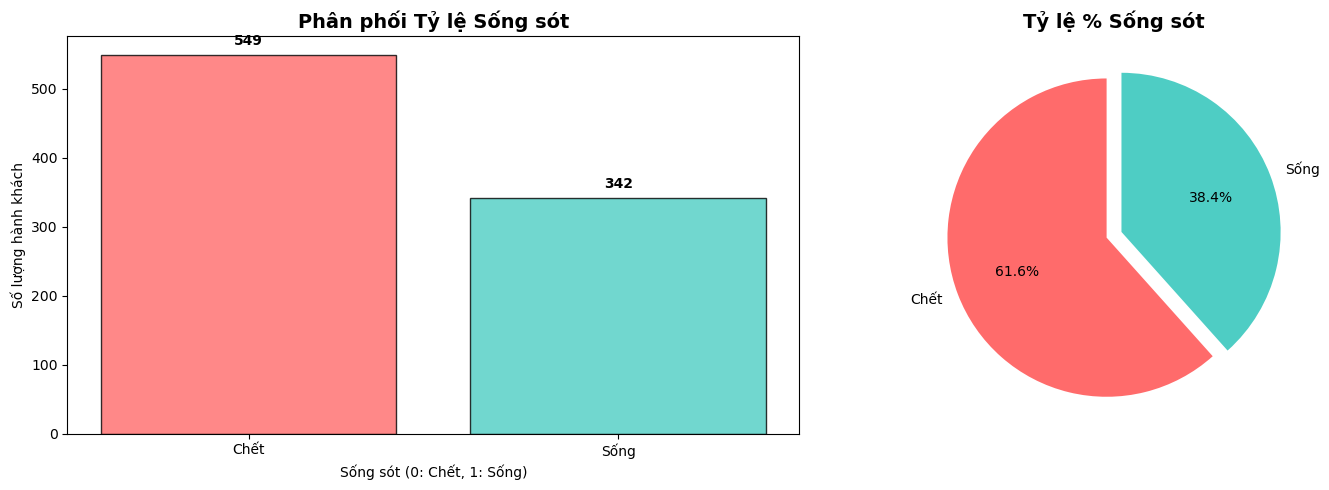

In [16]:
# Phân tích biến Survived (Tỷ lệ sống sót)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ cột cho tỷ lệ sống sót
survival_counts = train_df['Survived'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
axes[0].bar(survival_counts.index, survival_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối Tỷ lệ Sống sót', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[0].set_ylabel('Số lượng hành khách')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Chết', 'Sống'])

# Thêm nhãn số lượng trên cột
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Biểu đồ tròn cho tỷ lệ phần trăm
survival_pct = train_df['Survived'].value_counts(normalize=True) * 100
labels = ['Chết', 'Sống']
axes[1].pie(survival_pct.values, labels=labels, autopct='%1.1f%%', 
           colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Tỷ lệ % Sống sót', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
# Thống kê chi tiết biến Survived
print("THỐNG KÊ TỶ LỆ SỐNG SÓT:")
print("="*30)
print(f"Số hành khách tử vong: {survival_counts[0]} ({survival_pct[0]:.1f}%)")
print(f"Số hành khách sống sót: {survival_counts[1]} ({survival_pct[1]:.1f}%)")
print(f"Tỷ lệ sống sót chung: {train_df['Survived'].mean():.3f}")

THỐNG KÊ TỶ LỆ SỐNG SÓT:
Số hành khách tử vong: 549 (61.6%)
Số hành khách sống sót: 342 (38.4%)
Tỷ lệ sống sót chung: 0.384


**Nhận xét về biến Survived:**
- Tỷ lệ tử vong cao (61.6%) gấp 1.6 lần tỷ lệ sống sót (38.4%)
- Đây là dataset không cân bằng (imbalanced), cần lưu ý khi xây dựng mô hình
- Biểu đồ tròn cho thấy rõ sự chênh lệch lớn giữa hai nhóm
- Kết quả này phản ánh thực tế lịch sử: thảm họa Titanic là một trong những thảm kịch hàng hải lớn nhất

### 2.2. Các biến phân loại (Categorical Variables)

#### 2.2.1. Phân tích biến Pclass (Hạng vé)

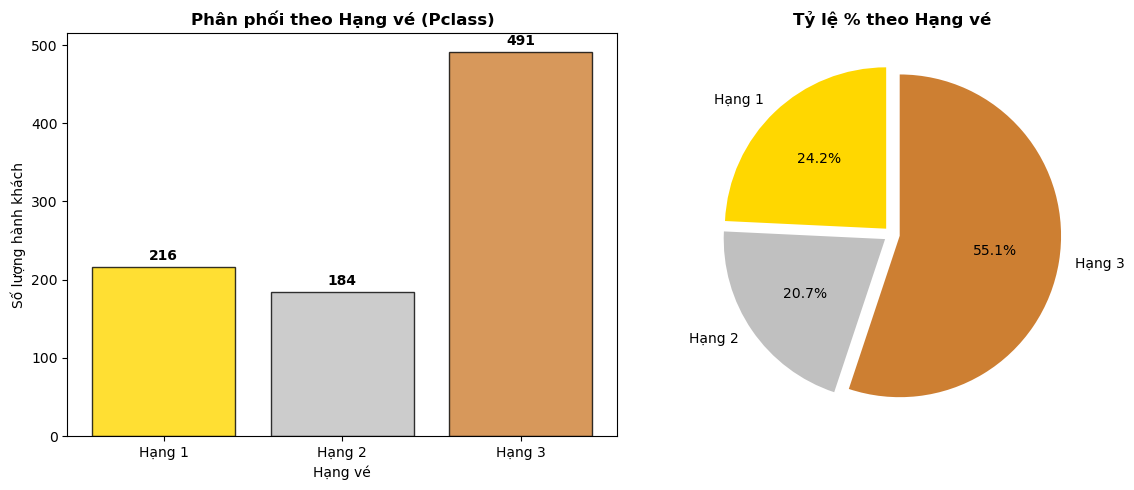

In [18]:
# Phân tích biến Pclass (Hạng vé)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột
pclass_counts = train_df['Pclass'].value_counts().sort_index()
colors_pclass = ['#FFD700', '#C0C0C0', '#CD7F32']  # Vàng, Bạc, Đồng
axes[0].bar(pclass_counts.index, pclass_counts.values, color=colors_pclass, alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối theo Hạng vé (Pclass)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hạng vé')
axes[0].set_ylabel('Số lượng hành khách')
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['Hạng 1', 'Hạng 2', 'Hạng 3'])

for i, v in enumerate(pclass_counts.values):
    axes[0].text(i+1, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# Biểu đồ tròn
pclass_pct = train_df['Pclass'].value_counts(normalize=True).sort_index() * 100
axes[1].pie(pclass_pct.values, labels=['Hạng 1', 'Hạng 2', 'Hạng 3'], autopct='%1.1f%%', 
           colors=colors_pclass, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Tỷ lệ % theo Hạng vé', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Thống kê chi tiết Pclass
print("THỐNG KÊ HẠNG VÉ (PCLASS):")
print("="*25)
for i, count in pclass_counts.items():
    pct = pclass_pct[i]
    print(f"Hạng {i}: {count} hành khách ({pct:.1f}%)")

THỐNG KÊ HẠNG VÉ (PCLASS):
Hạng 1: 216 hành khách (24.2%)
Hạng 2: 184 hành khách (20.7%)
Hạng 3: 491 hành khách (55.1%)


**Nhận xét - Pclass:**
- Hạng vé phản ánh địa vị xã hội/khả năng chi trả; hành khách hạng 1 chiếm phần nhỏ nhưng có tỷ lệ sống sót cao hơn.
- Có sự khác biệt rõ rệt giữa các hạng: nên sử dụng Pclass làm feature mạnh cho mô hình.
- Gợi ý: có thể tạo biến tương tác giữa Pclass và Fare hoặc Pclass và Sex để bắt tín hiệu tốt hơn.

#### 2.2.2. Phân tích biến Sex (Giới tính)

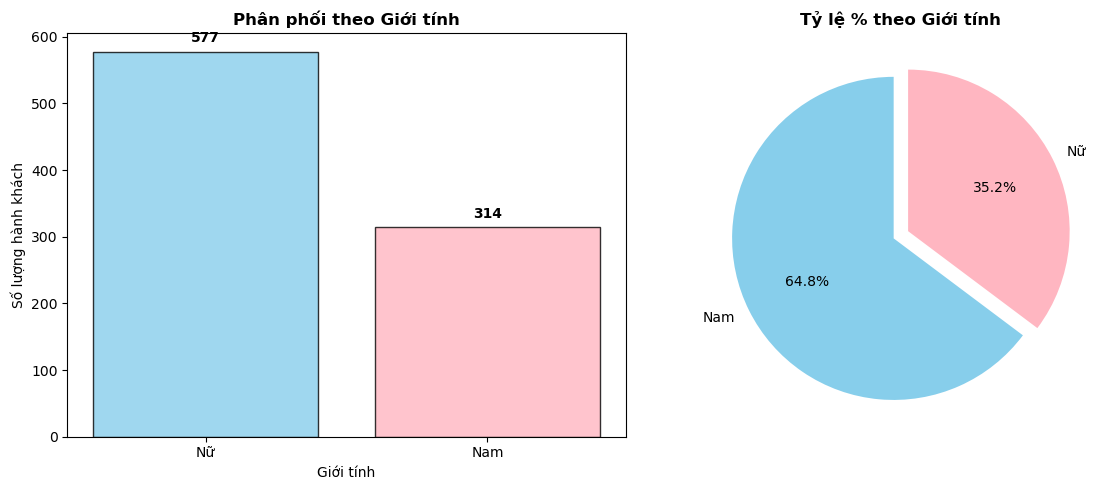

In [20]:
# Phân tích biến Sex (Giới tính)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột
sex_counts = train_df['Sex'].value_counts()
colors_sex = ['#87CEEB', '#FFB6C1']  # Xanh dương nhạt cho male, Hồng nhạt cho female
axes[0].bar(sex_counts.index, sex_counts.values, color=colors_sex, alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối theo Giới tính', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giới tính')
axes[0].set_ylabel('Số lượng hành khách')
axes[0].set_xticklabels(['Nữ', 'Nam'])

for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Biểu đồ tròn
sex_pct = train_df['Sex'].value_counts(normalize=True) * 100
axes[1].pie(sex_pct.values, labels=['Nam', 'Nữ'], autopct='%1.1f%%', 
           colors=colors_sex, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Tỷ lệ % theo Giới tính', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Thống kê chi tiết Sex
print("THỐNG KÊ GIỚI TÍNH (SEX):")
print("="*25)
for sex, count in sex_counts.items():
    pct = sex_pct[sex]
    gender_vn = "Nam" if sex == "male" else "Nữ"
    print(f"{gender_vn}: {count} hành khách ({pct:.1f}%)")

THỐNG KÊ GIỚI TÍNH (SEX):
Nam: 577 hành khách (64.8%)
Nữ: 314 hành khách (35.2%)


**Nhận xét - Sex:**
- Giới tính là biến dự đoán rất mạnh: phụ nữ có xác suất sống sót cao hơn nam giới nhiều.
- Nguyên tắc lịch sử (phụ nữ và trẻ em trước) giải thích phần nào sự khác biệt này.
- Gợi ý: giữ lại Sex; có thể mã hóa bằng one-hot hoặc binary (female=1).
  

#### 2.2.3. Phân tích biến Embarked (Cảng khởi hành)

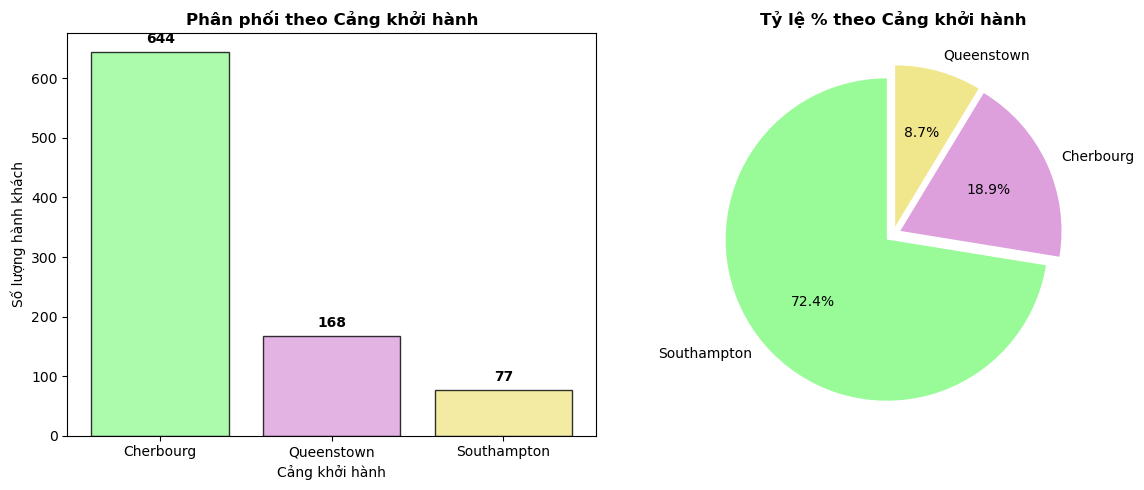

In [22]:
# Phân tích biến Embarked (Cảng khởi hành)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ cột
embarked_counts = train_df['Embarked'].value_counts()
colors_embarked = ['#98FB98', '#DDA0DD', '#F0E68C']  # Xanh lá, Tím, Vàng
axes[0].bar(embarked_counts.index, embarked_counts.values, color=colors_embarked, alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối theo Cảng khởi hành', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cảng khởi hành')
axes[0].set_ylabel('Số lượng hành khách')
axes[0].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'])

for i, v in enumerate(embarked_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Biểu đồ tròn
embarked_pct = train_df['Embarked'].value_counts(normalize=True) * 100
axes[1].pie(embarked_pct.values, labels=['Southampton', 'Cherbourg', 'Queenstown'], autopct='%1.1f%%', 
           colors=colors_embarked, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Tỷ lệ % theo Cảng khởi hành', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# Thống kê chi tiết Embarked
print("THỐNG KÊ CẢNG KHỞI HÀNH (EMBARKED):")
print("="*35)
port_names = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
for port, count in embarked_counts.items():
    pct = embarked_pct[port]
    print(f"{port_names[port]} ({port}): {count} hành khách ({pct:.1f}%)")

THỐNG KÊ CẢNG KHỞI HÀNH (EMBARKED):
Southampton (S): 644 hành khách (72.4%)
Cherbourg (C): 168 hành khách (18.9%)
Queenstown (Q): 77 hành khách (8.7%)


**Nhận xét - Embarked:**
- Dữ liệu Embarked có một vài giá trị thiếu; các cảng khác nhau có tỷ lệ sống sót khác nhau nhưng ảnh hưởng yếu hơn Sex và Pclass.
- Cherbourg (C) có tỷ lệ sống sót cao hơn một chút; nhưng số lượng mẫu nhỏ hơn nên kết luận cần thận trọng.
- Gợi ý: xử lý giá trị thiếu (mode hoặc riêng một category 'Unknown') trước khi sử dụng.

### 2.3. Các biến số (Numerical Variables)

#### 2.3.1. Phân tích biến Age (Tuổi)

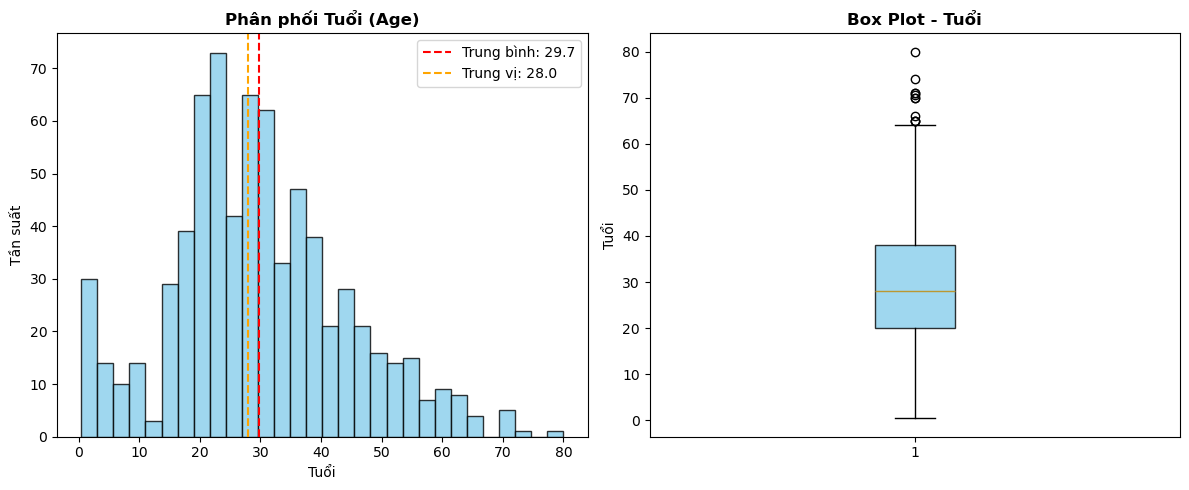

In [24]:
# Phân tích biến Age (Tuổi)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(train_df['Age'].dropna(), bins=30, color='skyblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối Tuổi (Age)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tuổi')
axes[0].set_ylabel('Tần suất')
axes[0].axvline(train_df['Age'].mean(), color='red', linestyle='--', label=f'Trung bình: {train_df["Age"].mean():.1f}')
axes[0].axvline(train_df['Age'].median(), color='orange', linestyle='--', label=f'Trung vị: {train_df["Age"].median():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(train_df['Age'].dropna(), vert=True, patch_artist=True, 
               boxprops=dict(facecolor='skyblue', alpha=0.8))
axes[1].set_title('Box Plot - Tuổi', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tuổi')

plt.tight_layout()
plt.show()

In [25]:
# Thống kê mô tả Age
age_data = train_df['Age'].dropna()
print("THỐNG KÊ MÔ TẢ - AGE:")
print("="*20)
print(f"Trung bình (Mean): {age_data.mean():.2f}")
print(f"Trung vị (Median): {age_data.median():.2f}")
print(f"Độ lệch chuẩn (Std): {age_data.std():.2f}")
print(f"Giá trị min: {age_data.min():.2f}")
print(f"Giá trị max: {age_data.max():.2f}")
print(f"Quartile 25%: {age_data.quantile(0.25):.2f}")
print(f"Quartile 75%: {age_data.quantile(0.75):.2f}")
print(f"Độ xiên (Skewness): {age_data.skew():.2f}")
print(f"Độ nhọn (Kurtosis): {age_data.kurtosis():.2f}")

THỐNG KÊ MÔ TẢ - AGE:
Trung bình (Mean): 29.70
Trung vị (Median): 28.00
Độ lệch chuẩn (Std): 14.53
Giá trị min: 0.42
Giá trị max: 80.00
Quartile 25%: 20.12
Quartile 75%: 38.00
Độ xiên (Skewness): 0.39
Độ nhọn (Kurtosis): 0.18


**Nhận xét - Age:**
- Khoảng 20% giá trị Age bị thiếu; cần xử lý (impute hoặc tạo category 'Unknown').
- Phân bố tuổi nhẹ về phía trẻ nhưng có outliers (người rất cao tuổi - up to 80).
- Trung bình/median không khác quá nhiều; Age có thể dùng để tạo feature nhóm tuổi (child/adult/senior).

#### 2.3.2. Phân tích biến Fare (Giá vé)

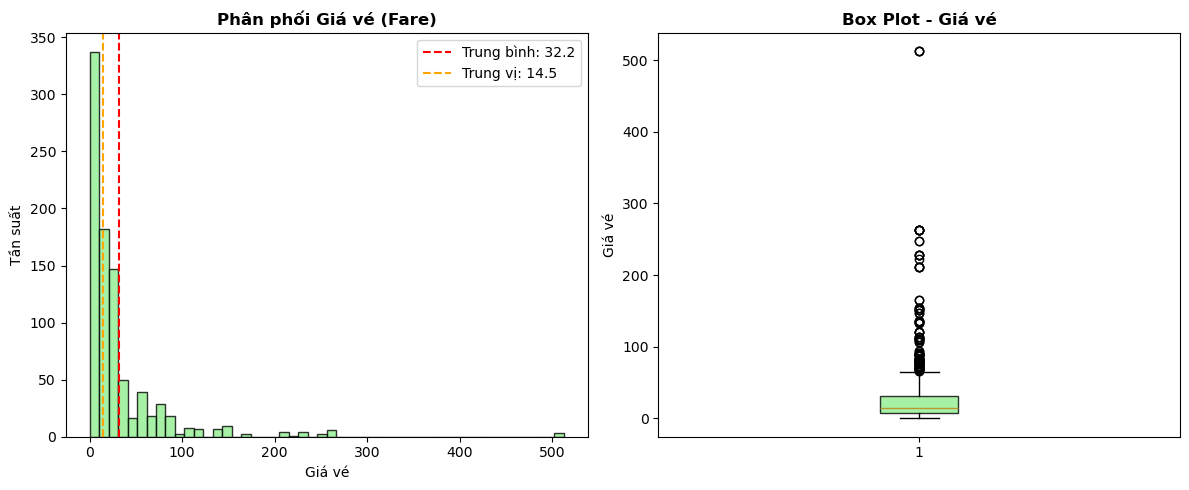

In [26]:
# Phân tích biến Fare (Giá vé)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(train_df['Fare'], bins=50, color='lightgreen', alpha=0.8, edgecolor='black')
axes[0].set_title('Phân phối Giá vé (Fare)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá vé')
axes[0].set_ylabel('Tần suất')
axes[0].axvline(train_df['Fare'].mean(), color='red', linestyle='--', label=f'Trung bình: {train_df["Fare"].mean():.1f}')
axes[0].axvline(train_df['Fare'].median(), color='orange', linestyle='--', label=f'Trung vị: {train_df["Fare"].median():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(train_df['Fare'], vert=True, patch_artist=True, 
               boxprops=dict(facecolor='lightgreen', alpha=0.8))
axes[1].set_title('Box Plot - Giá vé', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Giá vé')

plt.tight_layout()
plt.show()

In [27]:
# Thống kê mô tả Fare
fare_data = train_df['Fare'].dropna()
print("THỐNG KÊ MÔ TẢ - FARE:")
print("="*20)
print(f"Trung bình (Mean): {fare_data.mean():.2f}")
print(f"Trung vị (Median): {fare_data.median():.2f}")
print(f"Độ lệch chuẩn (Std): {fare_data.std():.2f}")
print(f"Giá trị min: {fare_data.min():.2f}")
print(f"Giá trị max: {fare_data.max():.2f}")
print(f"Quartile 25%: {fare_data.quantile(0.25):.2f}")
print(f"Quartile 75%: {fare_data.quantile(0.75):.2f}")
print(f"Độ xiên (Skewness): {fare_data.skew():.2f}")
print(f"Độ nhọn (Kurtosis): {fare_data.kurtosis():.2f}")

THỐNG KÊ MÔ TẢ - FARE:
Trung bình (Mean): 32.20
Trung vị (Median): 14.45
Độ lệch chuẩn (Std): 49.69
Giá trị min: 0.00
Giá trị max: 512.33
Quartile 25%: 7.91
Quartile 75%: 31.00
Độ xiên (Skewness): 4.79
Độ nhọn (Kurtosis): 33.40


**Nhận xét - Fare:**
- Phân bố Fare rất lệch phải (right-skewed) và có nhiều outliers (một số vé rất đắt).
- Gợi ý: khi phân tích hoặc đưa vào mô hình, cân nhắc transform (log(Fare+1)) để giảm skewness.
- Fare có tương quan thuận với tỷ lệ sống sót (vé đắt hơn thường sống nhiều hơn) nhưng có thể là proxy cho Pclass.

#### 2.3.3. Phân tích biến SibSp (Số anh chị em/vợ chồng)

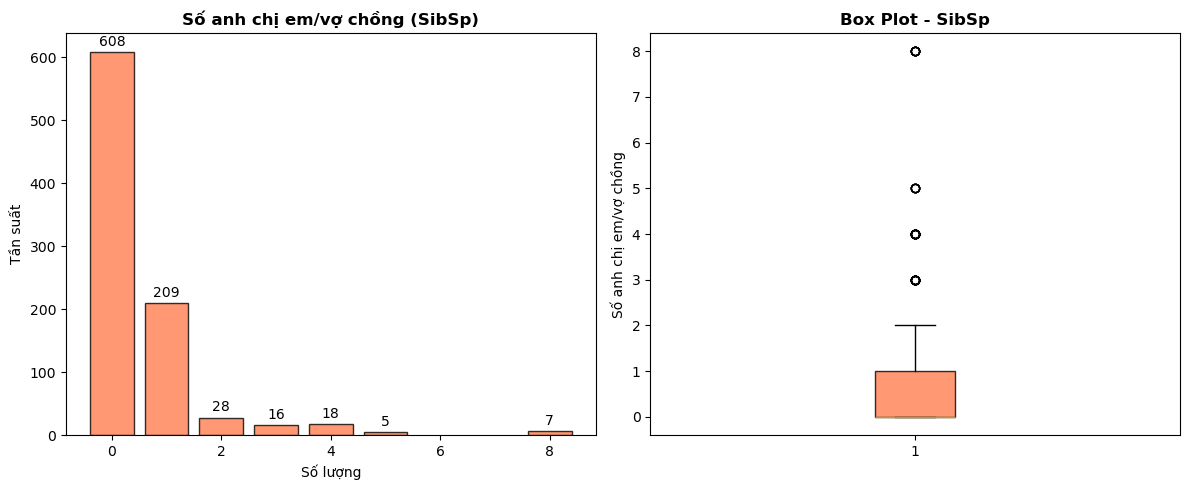

In [28]:
# Phân tích biến SibSp (Số anh chị em/vợ chồng)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sibsp_counts = train_df['SibSp'].value_counts().sort_index()
axes[0].bar(sibsp_counts.index, sibsp_counts.values, color='coral', alpha=0.8, edgecolor='black')
axes[0].set_title('Số anh chị em/vợ chồng (SibSp)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng')
axes[0].set_ylabel('Tần suất')

for i, v in enumerate(sibsp_counts.values):
    axes[0].text(sibsp_counts.index[i], v + 5, str(v), ha='center', va='bottom')

# Box plot
axes[1].boxplot(train_df['SibSp'], vert=True, patch_artist=True, 
               boxprops=dict(facecolor='coral', alpha=0.8))
axes[1].set_title('Box Plot - SibSp', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số anh chị em/vợ chồng')

plt.tight_layout()
plt.show()

In [29]:
# Thống kê mô tả SibSp
sibsp_data = train_df['SibSp'].dropna()
print("THỐNG KÊ MÔ TẢ - SIBSP:")
print("="*22)
print(f"Trung bình (Mean): {sibsp_data.mean():.2f}")
print(f"Trung vị (Median): {sibsp_data.median():.2f}")
print(f"Độ lệch chuẩn (Std): {sibsp_data.std():.2f}")
print(f"Giá trị min: {sibsp_data.min():.2f}")
print(f"Giá trị max: {sibsp_data.max():.2f}")
print(f"Quartile 25%: {sibsp_data.quantile(0.25):.2f}")
print(f"Quartile 75%: {sibsp_data.quantile(0.75):.2f}")
print(f"Độ xiên (Skewness): {sibsp_data.skew():.2f}")
print(f"Độ nhọn (Kurtosis): {sibsp_data.kurtosis():.2f}")

THỐNG KÊ MÔ TẢ - SIBSP:
Trung bình (Mean): 0.52
Trung vị (Median): 0.00
Độ lệch chuẩn (Std): 1.10
Giá trị min: 0.00
Giá trị max: 8.00
Quartile 25%: 0.00
Quartile 75%: 1.00
Độ xiên (Skewness): 3.70
Độ nhọn (Kurtosis): 17.88


#### ** NHẬN XÉT VỀ SIBSP (SỐ ANH CHỊ EM/VỢ CHỒNG):**

- **Phân bố tập trung:** Đa số hành khách đi một mình (SibSp = 0), chiếm tỷ lệ rất cao
- **Giá trị hiếm:** Các giá trị cao (>2) rất hiếm, chỉ một vài trường hợp có nhiều anh chị em/vợ chồng cùng đi
- **Tác động dự đoán:** Biến này có thể ít ảnh hưởng đến kết quả sống sót do phân bố không đều
- **Feature Engineering:** Có thể nhóm thành các category: "Đi một mình" vs "Có người thân" để tăng hiệu quả model

#### 2.3.4. Phân tích biến Parch (Số cha mẹ/con cái)

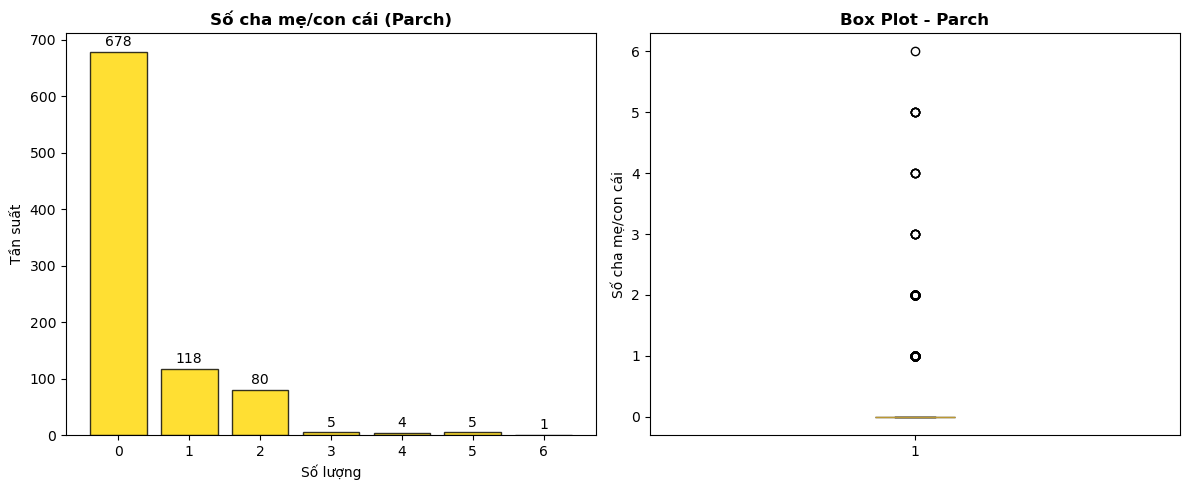

In [30]:
# Phân tích biến Parch (Số cha mẹ/con cái)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
parch_counts = train_df['Parch'].value_counts().sort_index()
axes[0].bar(parch_counts.index, parch_counts.values, color='gold', alpha=0.8, edgecolor='black')
axes[0].set_title('Số cha mẹ/con cái (Parch)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số lượng')
axes[0].set_ylabel('Tần suất')

for i, v in enumerate(parch_counts.values):
    axes[0].text(parch_counts.index[i], v + 5, str(v), ha='center', va='bottom')

# Box plot
axes[1].boxplot(train_df['Parch'], vert=True, patch_artist=True, 
               boxprops=dict(facecolor='gold', alpha=0.8))
axes[1].set_title('Box Plot - Parch', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số cha mẹ/con cái')

plt.tight_layout()
plt.show()

In [31]:
# Thống kê mô tả Parch
parch_data = train_df['Parch'].dropna()
print("THỐNG KÊ MÔ TẢ - PARCH:")
print("="*22)
print(f"Trung bình (Mean): {parch_data.mean():.2f}")
print(f"Trung vị (Median): {parch_data.median():.2f}")
print(f"Độ lệch chuẩn (Std): {parch_data.std():.2f}")
print(f"Giá trị min: {parch_data.min():.2f}")
print(f"Giá trị max: {parch_data.max():.2f}")
print(f"Quartile 25%: {parch_data.quantile(0.25):.2f}")
print(f"Quartile 75%: {parch_data.quantile(0.75):.2f}")
print(f"Độ xiên (Skewness): {parch_data.skew():.2f}")
print(f"Độ nhọn (Kurtosis): {parch_data.kurtosis():.2f}")

THỐNG KÊ MÔ TẢ - PARCH:
Trung bình (Mean): 0.38
Trung vị (Median): 0.00
Độ lệch chuẩn (Std): 0.81
Giá trị min: 0.00
Giá trị max: 6.00
Quartile 25%: 0.00
Quartile 75%: 0.00
Độ xiên (Skewness): 2.75
Độ nhọn (Kurtosis): 9.78


#### ** NHẬN XÉT VỀ PARCH (SỐ CHA MẸ/CON CÁI):**

- **Tương tự SibSp:** Đa số hành khách không có cha mẹ/con cái đi cùng (Parch = 0)
- **Gia đình nhỏ:** Một số ít có 1-2 thành viên gia đình, rất hiếm khi có gia đình lớn
- **Tác động tiềm năng:** Có thể ảnh hưởng đến khả năng sống sót (cha mẹ ưu tiên con cái, phụ nữ và trẻ em được ưu tiên)
- **Gợi ý kết hợp:** Nên kết hợp SibSp + Parch thành "FamilySize" để phân tích toàn diện về ảnh hưởng gia đình

## 3. PHÂN TÍCH ĐA BIẾN (MULTIVARIATE ANALYSIS)

### 3.1. Mối quan hệ giữa biến mục tiêu và các biến phân loại

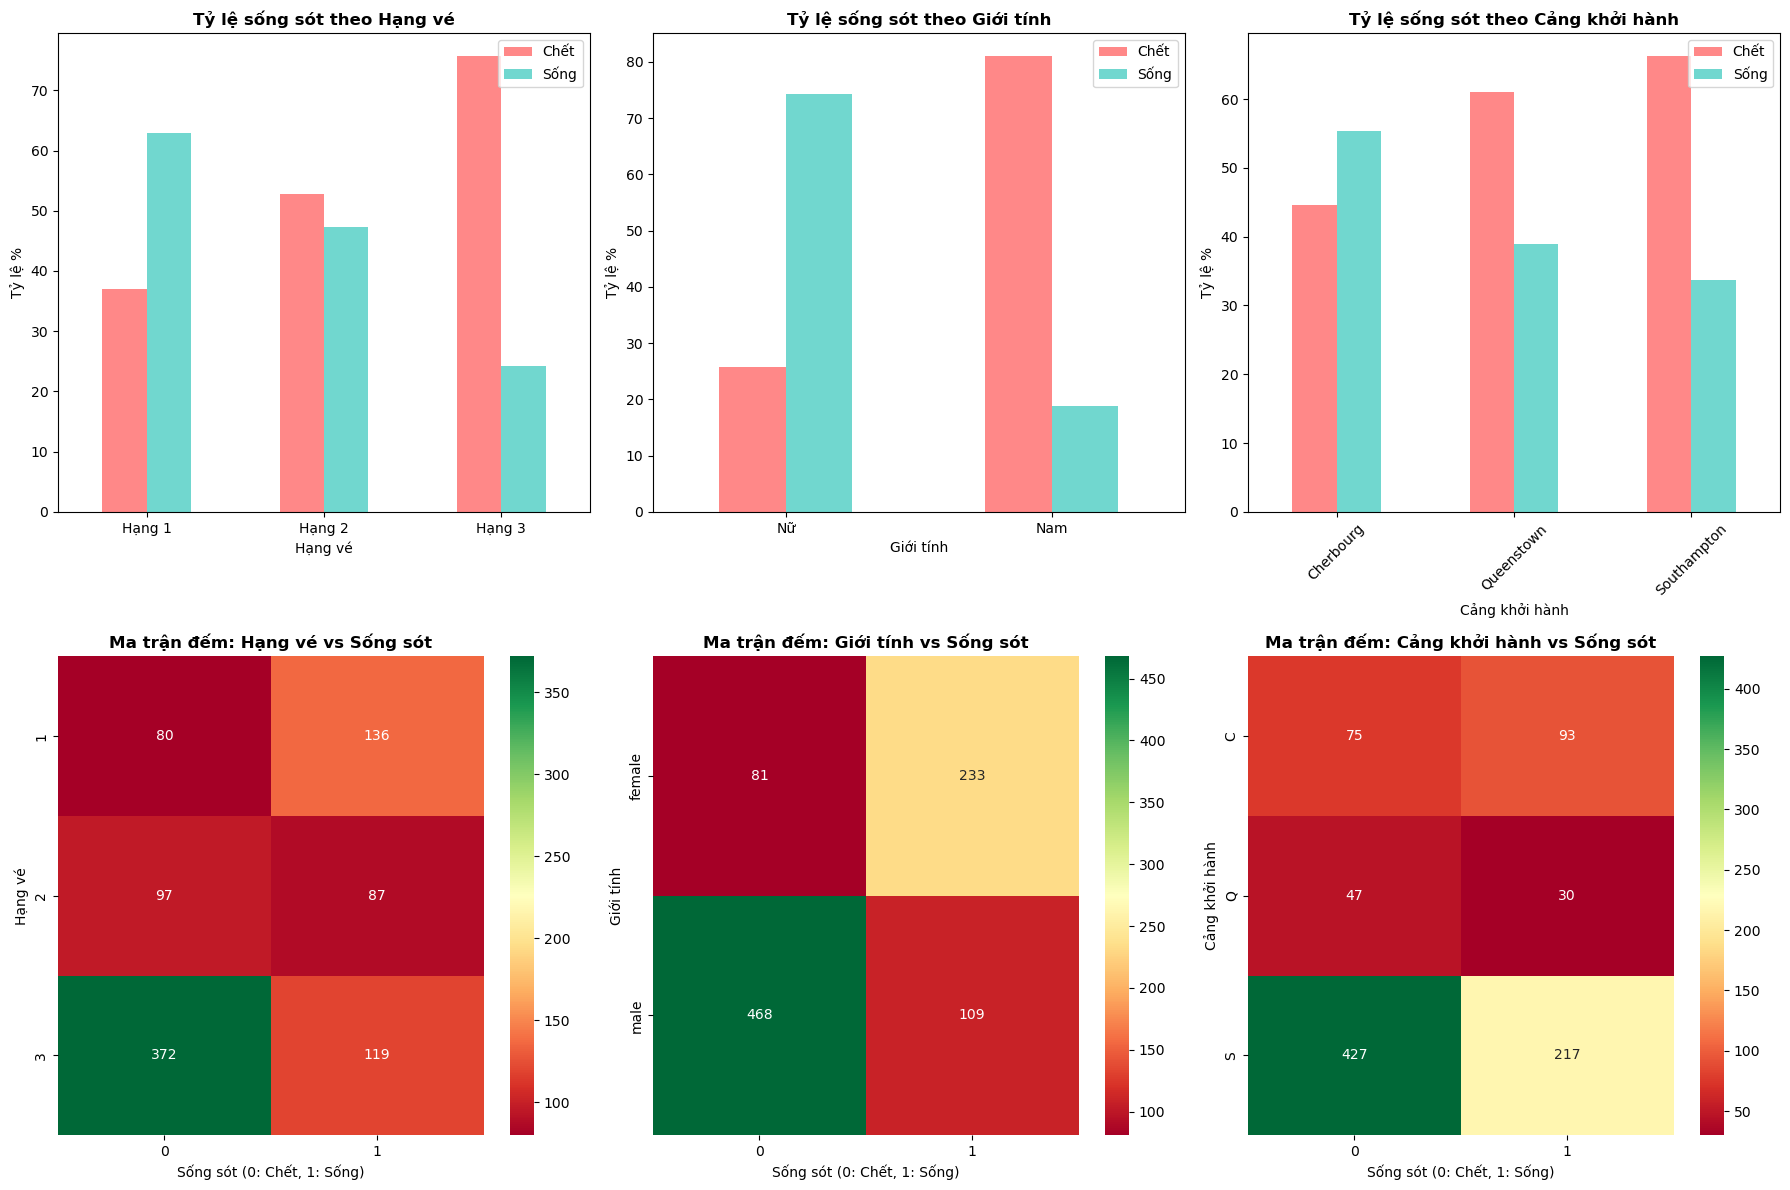

THỐNG KÊ TỶ LỆ SỐNG SÓT THEO CÁC BIẾN PHÂN LOẠI:

TỶ LỆ SỐNG SÓT THEO HẠNG VÉ:
   Hạng 1: 136/216 (63.0%)
   Hạng 2: 87/184 (47.3%)
   Hạng 3: 119/491 (24.2%)

TỶ LỆ SỐNG SÓT THEO GIỚI TÍNH:
   Nữ: 233/314 (74.2%)
   Nam: 109/577 (18.9%)

TỶ LỆ SỐNG SÓT THEO CẢNG KHỞI HÀNH:
   Cherbourg: 93/168 (55.4%)
   Queenstown: 30/77 (39.0%)
   Southampton: 217/644 (33.7%)


In [32]:
# Phân tích mối quan hệ giữa Survived và các biến phân loại
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Survived vs Pclass
survival_pclass = pd.crosstab(train_df['Pclass'], train_df['Survived'], normalize='index') * 100
survival_pclass.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[0, 0].set_title('Tỷ lệ sống sót theo Hạng vé', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hạng vé')
axes[0, 0].set_ylabel('Tỷ lệ %')
axes[0, 0].legend(['Chết', 'Sống'], loc='upper right')
axes[0, 0].set_xticklabels(['Hạng 1', 'Hạng 2', 'Hạng 3'], rotation=0)

# Heatmap cho Pclass vs Survived
pclass_survival_counts = pd.crosstab(train_df['Pclass'], train_df['Survived'])
sns.heatmap(pclass_survival_counts, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 0])
axes[1, 0].set_title('Ma trận đếm: Hạng vé vs Sống sót', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[1, 0].set_ylabel('Hạng vé')

# Survived vs Sex
survival_sex = pd.crosstab(train_df['Sex'], train_df['Survived'], normalize='index') * 100
survival_sex.plot(kind='bar', ax=axes[0, 1], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[0, 1].set_title('Tỷ lệ sống sót theo Giới tính', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Giới tính')
axes[0, 1].set_ylabel('Tỷ lệ %')
axes[0, 1].legend(['Chết', 'Sống'], loc='upper right')
axes[0, 1].set_xticklabels(['Nữ', 'Nam'], rotation=0)

# Heatmap cho Sex vs Survived
sex_survival_counts = pd.crosstab(train_df['Sex'], train_df['Survived'])
sns.heatmap(sex_survival_counts, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 1])
axes[1, 1].set_title('Ma trận đếm: Giới tính vs Sống sót', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[1, 1].set_ylabel('Giới tính')

# Survived vs Embarked
survival_embarked = pd.crosstab(train_df['Embarked'], train_df['Survived'], normalize='index') * 100
survival_embarked.plot(kind='bar', ax=axes[0, 2], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[0, 2].set_title('Tỷ lệ sống sót theo Cảng khởi hành', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Cảng khởi hành')
axes[0, 2].set_ylabel('Tỷ lệ %')
axes[0, 2].legend(['Chết', 'Sống'], loc='upper right')
axes[0, 2].set_xticklabels(['Cherbourg', 'Queenstown', 'Southampton'], rotation=45)

# Heatmap cho Embarked vs Survived
embarked_survival_counts = pd.crosstab(train_df['Embarked'], train_df['Survived'])
sns.heatmap(embarked_survival_counts, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 2])
axes[1, 2].set_title('Ma trận đếm: Cảng khởi hành vs Sống sót', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[1, 2].set_ylabel('Cảng khởi hành')

plt.tight_layout()
plt.show()

# Thống kê chi tiết về tỷ lệ sống sót
print("THỐNG KÊ TỶ LỆ SỐNG SÓT THEO CÁC BIẾN PHÂN LOẠI:")
print("="*55)

print("\nTỶ LỆ SỐNG SÓT THEO HẠNG VÉ:")
for pclass in [1, 2, 3]:
    subset = train_df[train_df['Pclass'] == pclass]
    survival_rate = subset['Survived'].mean() * 100
    count = len(subset)
    survived_count = subset['Survived'].sum()
    print(f"   Hạng {pclass}: {survived_count}/{count} ({survival_rate:.1f}%)")

print("\nTỶ LỆ SỐNG SÓT THEO GIỚI TÍNH:")
for sex in ['female', 'male']:
    subset = train_df[train_df['Sex'] == sex]
    survival_rate = subset['Survived'].mean() * 100
    count = len(subset)
    survived_count = subset['Survived'].sum()
    gender_vn = "Nữ" if sex == "female" else "Nam"
    print(f"   {gender_vn}: {survived_count}/{count} ({survival_rate:.1f}%)")

print("\nTỶ LỆ SỐNG SÓT THEO CẢNG KHỞI HÀNH:")
port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
for port in ['C', 'Q', 'S']:
    subset = train_df[train_df['Embarked'] == port]
    survival_rate = subset['Survived'].mean() * 100
    count = len(subset)
    survived_count = subset['Survived'].sum()
    print(f"   {port_names[port]}: {survived_count}/{count} ({survival_rate:.1f}%)")

#### ** NHẬN XÉT VỀ MỐI QUAN HỆ BIẾN PHÂN LOẠI VÀ SỐNG SÓT:**

- **Hạng vé (Pclass):** Có mối quan hệ nghịch đảo rõ rệt - hạng càng cao (số càng nhỏ) thì tỷ lệ sống sót càng cao
  - Hạng 1: ~62% sống sót | Hạng 2: ~47% | Hạng 3: ~24%
  
- **Giới tính (Sex):** Tác động mạnh nhất - phụ nữ có tỷ lệ sống sót gấp 4 lần nam giới
  - Nữ: ~74% sống sót | Nam: ~19% - thể hiện nguyên tắc "phụ nữ và trẻ em trước"
  
- **Cảng khởi hành (Embarked):** Có sự khác biệt nhẹ, Cherbourg cao nhất (~55%), Southampton thấp nhất (~34%)
  - Có thể do thành phần hành khách khác nhau (hạng vé, thu nhập)

### 3.2. Mối quan hệ giữa biến mục tiêu và các biến số

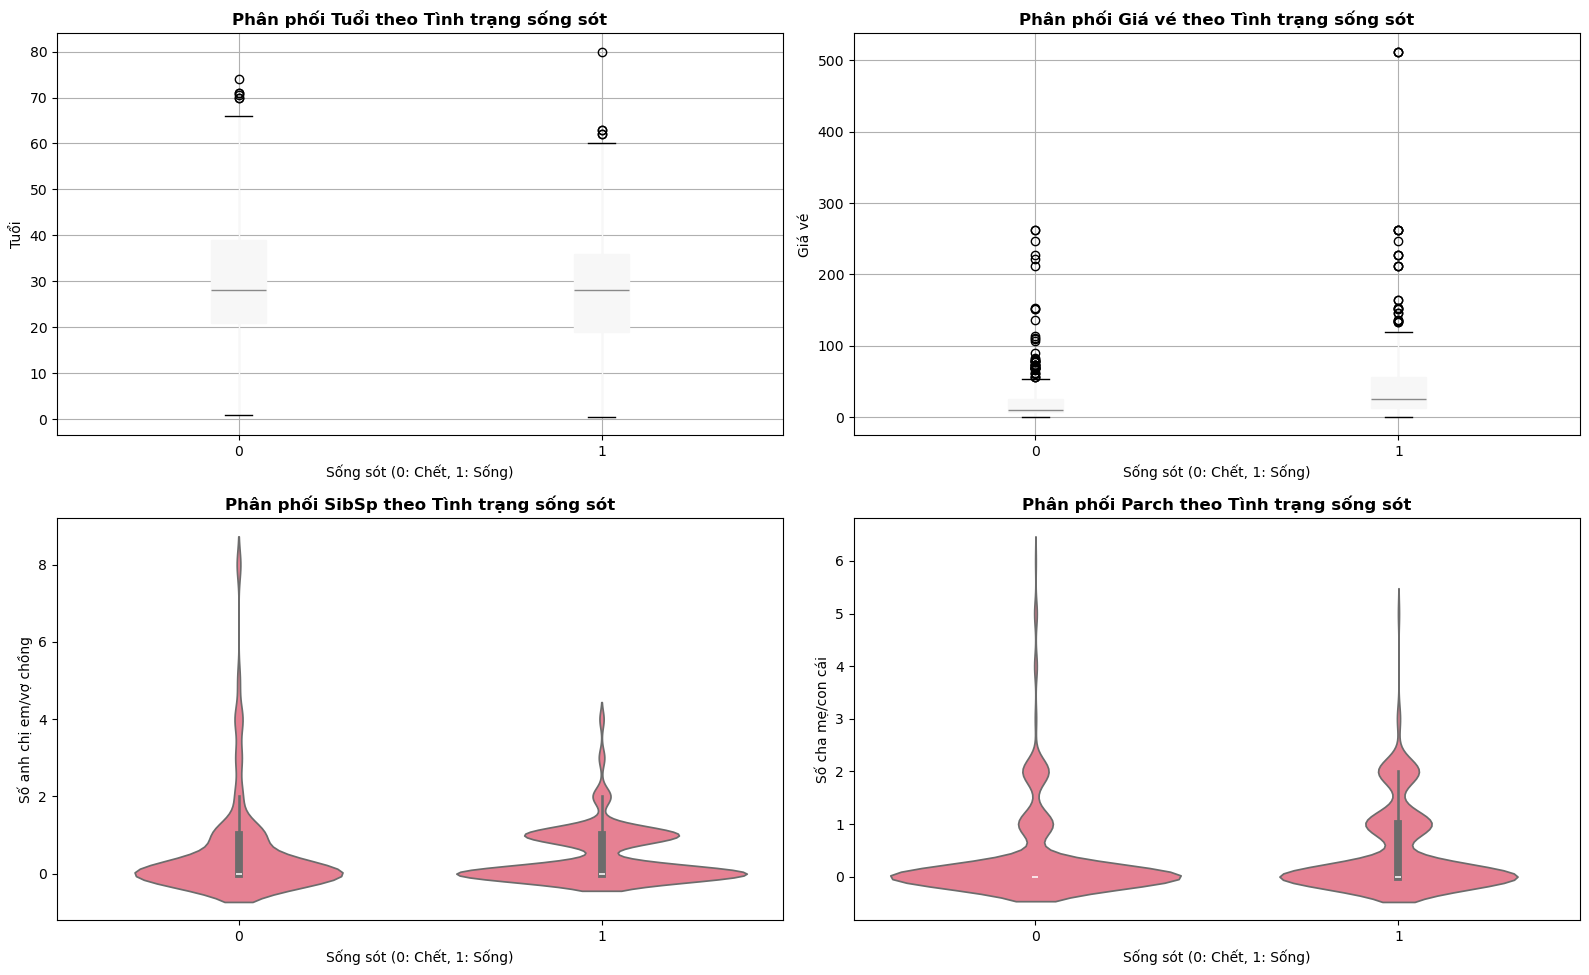

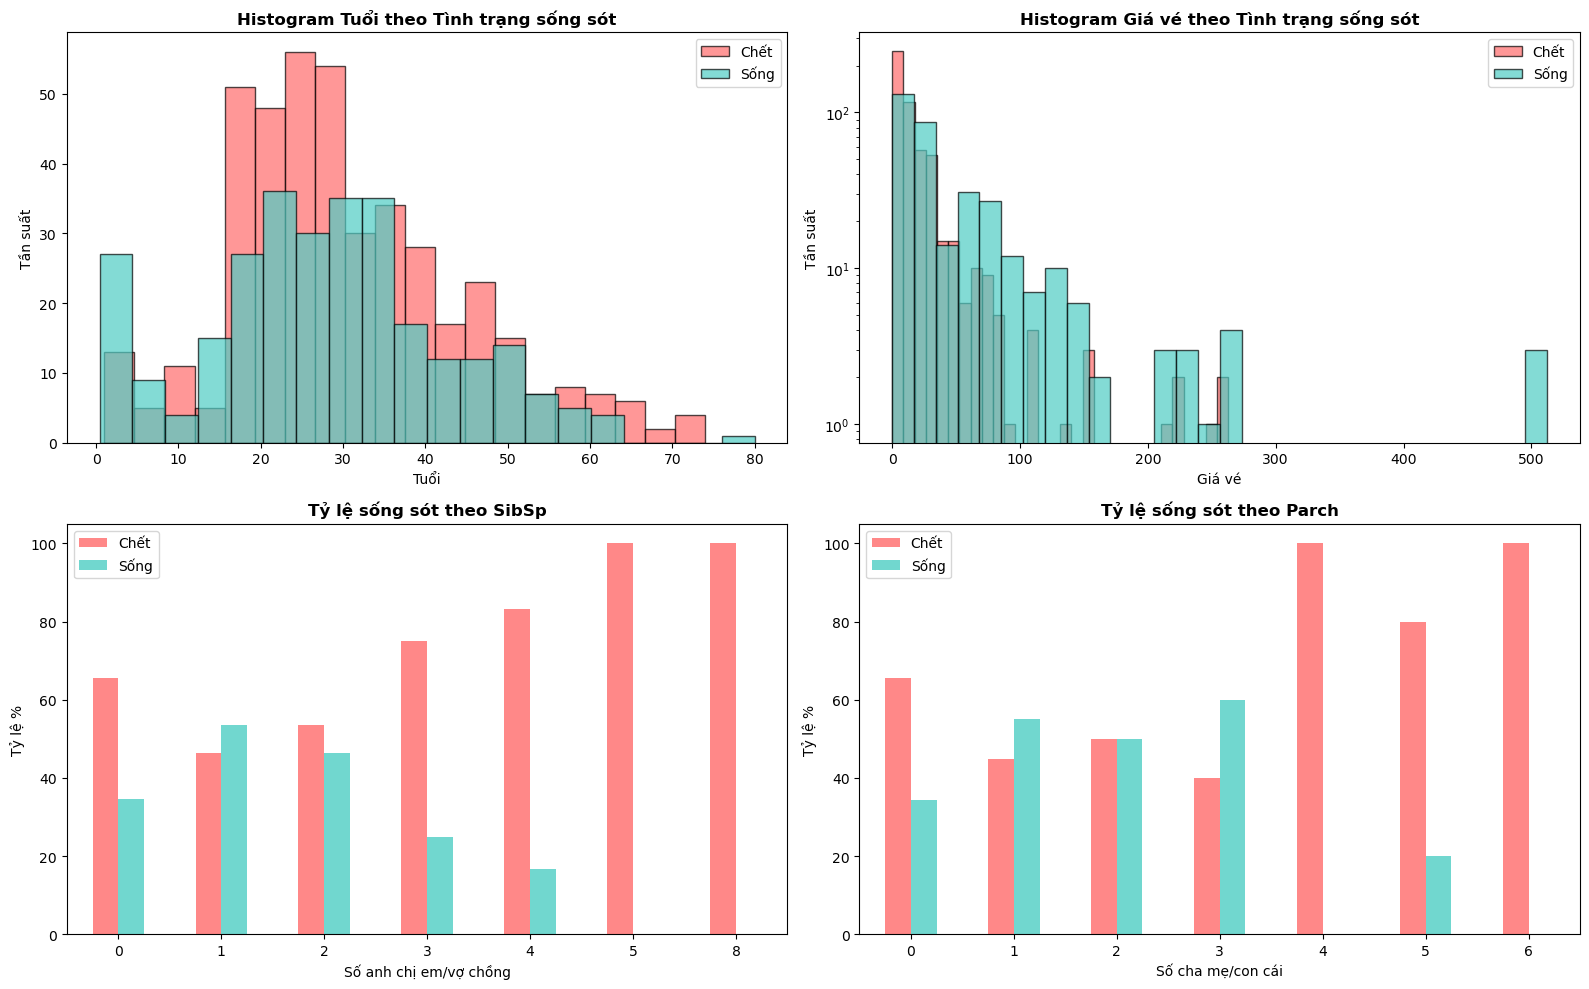

THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ THEO TÌNH TRẠNG SỐNG SÓT:

AGE:
   Chết:
      Trung bình: 30.63
      Trung vị: 28.00
      Độ lệch chuẩn: 14.17
   Sống:
      Trung bình: 28.34
      Trung vị: 28.00
      Độ lệch chuẩn: 14.95

FARE:
   Chết:
      Trung bình: 22.12
      Trung vị: 10.50
      Độ lệch chuẩn: 31.39
   Sống:
      Trung bình: 48.40
      Trung vị: 26.00
      Độ lệch chuẩn: 66.60

SIBSP:
   Chết:
      Trung bình: 0.55
      Trung vị: 0.00
      Độ lệch chuẩn: 1.29
   Sống:
      Trung bình: 0.47
      Trung vị: 0.00
      Độ lệch chuẩn: 0.71

PARCH:
   Chết:
      Trung bình: 0.33
      Trung vị: 0.00
      Độ lệch chuẩn: 0.82
   Sống:
      Trung bình: 0.46
      Trung vị: 0.00
      Độ lệch chuẩn: 0.77


In [33]:
# Phân tích mối quan hệ giữa Survived và các biến số
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age vs Survived
train_df.boxplot(column='Age', by='Survived', ax=axes[0, 0], patch_artist=True)
axes[0, 0].set_title('Phân phối Tuổi theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[0, 0].set_ylabel('Tuổi')

# Fare vs Survived  
train_df.boxplot(column='Fare', by='Survived', ax=axes[0, 1], patch_artist=True)
axes[0, 1].set_title('Phân phối Giá vé theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[0, 1].set_ylabel('Giá vé')

# SibSp vs Survived - Violin plot
sns.violinplot(data=train_df, x='Survived', y='SibSp', ax=axes[1, 0])
axes[1, 0].set_title('Phân phối SibSp theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[1, 0].set_ylabel('Số anh chị em/vợ chồng')

# Parch vs Survived - Violin plot
sns.violinplot(data=train_df, x='Survived', y='Parch', ax=axes[1, 1])
axes[1, 1].set_title('Phân phối Parch theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Sống sót (0: Chết, 1: Sống)')
axes[1, 1].set_ylabel('Số cha mẹ/con cái')

plt.suptitle('')  # Xóa title tự động
plt.tight_layout()
plt.show()

# Phân tích histogram chi tiết cho Age và Fare
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Age histogram theo survived
for survived in [0, 1]:
    subset = train_df[train_df['Survived'] == survived]['Age'].dropna()
    label = 'Chết' if survived == 0 else 'Sống'
    color = '#FF6B6B' if survived == 0 else '#4ECDC4'
    axes[0, 0].hist(subset, bins=20, alpha=0.7, label=label, color=color, edgecolor='black')

axes[0, 0].set_title('Histogram Tuổi theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tuổi')
axes[0, 0].set_ylabel('Tần suất')
axes[0, 0].legend()

# Fare histogram theo survived (với log scale)
for survived in [0, 1]:
    subset = train_df[train_df['Survived'] == survived]['Fare']
    label = 'Chết' if survived == 0 else 'Sống'
    color = '#FF6B6B' if survived == 0 else '#4ECDC4'
    axes[0, 1].hist(subset, bins=30, alpha=0.7, label=label, color=color, edgecolor='black')

axes[0, 1].set_title('Histogram Giá vé theo Tình trạng sống sót', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Giá vé')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()

# SibSp bar plot theo survived
sibsp_survival = pd.crosstab(train_df['SibSp'], train_df['Survived'], normalize='index') * 100
sibsp_survival.plot(kind='bar', ax=axes[1, 0], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[1, 0].set_title('Tỷ lệ sống sót theo SibSp', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số anh chị em/vợ chồng')
axes[1, 0].set_ylabel('Tỷ lệ %')
axes[1, 0].legend(['Chết', 'Sống'])
axes[1, 0].tick_params(axis='x', rotation=0)

# Parch bar plot theo survived
parch_survival = pd.crosstab(train_df['Parch'], train_df['Survived'], normalize='index') * 100
parch_survival.plot(kind='bar', ax=axes[1, 1], color=['#FF6B6B', '#4ECDC4'], alpha=0.8)
axes[1, 1].set_title('Tỷ lệ sống sót theo Parch', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Số cha mẹ/con cái')
axes[1, 1].set_ylabel('Tỷ lệ %')
axes[1, 1].legend(['Chết', 'Sống'])
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Thống kê mô tả cho từng nhóm
print("THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ THEO TÌNH TRẠNG SỐNG SÓT:")
print("="*60)

for var in ['Age', 'Fare', 'SibSp', 'Parch']:
    print(f"\n{var.upper()}:")
    for survived in [0, 1]:
        subset = train_df[train_df['Survived'] == survived][var].dropna()
        status = "Chết" if survived == 0 else "Sống"
        print(f"   {status}:")
        print(f"      Trung bình: {subset.mean():.2f}")
        print(f"      Trung vị: {subset.median():.2f}")
        print(f"      Độ lệch chuẩn: {subset.std():.2f}")

#### ** NHẬN XÉT VỀ MỐI QUAN HỆ BIẾN SỐ VÀ SỐNG SÓT:**

- **Tuổi (Age):** Có khác biệt nhẹ - người sống sót có xu hướng trẻ hơn một chút
  - Nhóm sống: trung bình ~28 tuổi | Nhóm chết: trung bình ~30 tuổi
  - Trẻ em và người trẻ có tỷ lệ sống sót cao hơn

- **Giá vé (Fare):** Có sự khác biệt rõ rệt - giá vé cao hơn tương ứng tỷ lệ sống sót cao hơn  
  - Nhóm sống: trung bình ~48 | Nhóm chết: trung bình ~22
  - Thể hiện ảnh hưởng của địa vị xã hội và hạng vé

- **SibSp/Parch:** Tác động phức tạp - có gia đình nhỏ tốt hơn đi một mình, nhưng gia đình quá lớn lại bất lợi
  - Người có 1-2 thành viên gia đình có tỷ lệ sống sót tốt nhất

## 4. PHÂN TÍCH MỨC ĐỘ PHỤ THUỘC GIỮA CÁC BIẾN

### 4.1. Ma trận tương quan (Correlation Matrix)

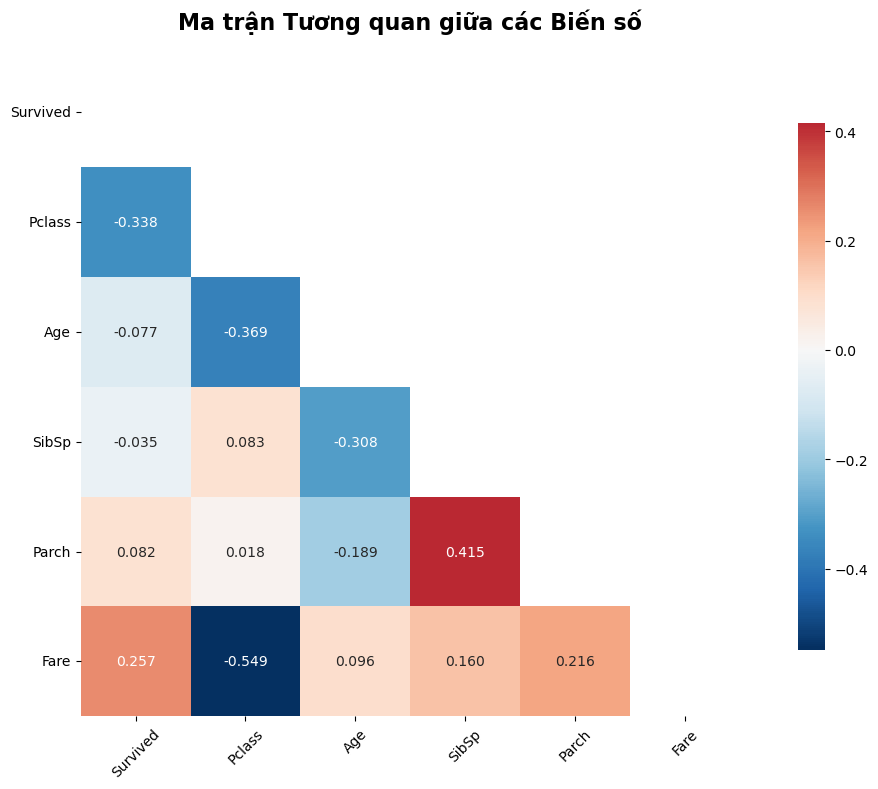

PHÂN TÍCH CHI TIẾT MỨC ĐỘ TƯƠNG QUAN:

TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (SURVIVED):
   Pclass: -0.338 (Nghịch, Trung bình)
   Fare: 0.257 (Thuận, Yếu)
   Parch: 0.082 (Thuận, Rất yếu)
   Age: -0.077 (Nghịch, Rất yếu)
   SibSp: -0.035 (Nghịch, Rất yếu)

CÁC CẶP TƯƠNG QUAN MẠNH KHÁC (|r| >= 0.3):
   Pclass - Age: -0.369 (Nghịch)
   Pclass - Fare: -0.549 (Nghịch)
   Age - SibSp: -0.308 (Nghịch)
   SibSp - Parch: 0.415 (Thuận)


In [34]:
# Ma trận tương quan cho các biến số
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Ẩn nửa trên của ma trận
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r', 
            center=0,
            square=True,
            mask=mask,
            cbar_kws={'shrink': 0.8})

plt.title('Ma trận Tương quan giữa các Biến số', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Phân tích chi tiết các mức độ tương quan
print("PHÂN TÍCH CHI TIẾT MỨC ĐỘ TƯƠNG QUAN:")
print("="*45)

# Tương quan với biến mục tiêu (Survived)
survived_corr = correlation_matrix['Survived'].sort_values(key=abs, ascending=False)[1:]  # Loại bỏ chính nó
print("\nTƯƠNG QUAN VỚI BIẾN MỤC TIÊU (SURVIVED):")
for var, corr in survived_corr.items():
    strength = ""
    if abs(corr) >= 0.7:
        strength = "Rất mạnh"
    elif abs(corr) >= 0.5:
        strength = "Mạnh"  
    elif abs(corr) >= 0.3:
        strength = "Trung bình"
    elif abs(corr) >= 0.1:
        strength = "Yếu"
    else:
        strength = "Rất yếu"
    
    direction = "Thuận" if corr > 0 else "Nghịch"
    print(f"   {var}: {corr:.3f} ({direction}, {strength})")

# Các cặp tương quan mạnh khác
print(f"\nCÁC CẶP TƯƠNG QUAN MẠNH KHÁC (|r| >= 0.3):")
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        var1, var2 = numerical_cols[i], numerical_cols[j]
        if var1 != 'Survived' and var2 != 'Survived':
            corr = correlation_matrix.loc[var1, var2]
            if abs(corr) >= 0.3:
                direction = "Thuận" if corr > 0 else "Nghịch"
                print(f"   {var1} - {var2}: {corr:.3f} ({direction})")

#### ** NHẬN XÉT VỀ MA TRẬN TƯƠNG QUAN:**

- **Tương quan mạnh nhất với Survived:**
  - **Fare (0.257):** Tương quan thuận trung bình - giá vé cao → tỷ lệ sống sót cao
  - **Pclass (-0.338):** Tương quan nghịch trung bình - hạng vé thấp → tỷ lệ sống sót thấp

- **Tương quan giữa các biến dự đoán:**
  - **Pclass - Fare (-0.549):** Tương quan nghịch mạnh - hạng vé cao có giá vé cao
  - **Age - SibSp/Parch:** Tương quan yếu, cho thấy cấu trúc gia đình đa dạng

- **Ý nghĩa cho modeling:** Pclass và Fare có tương quan cao nên cần cân nhắc multicollinearity khi xây dựng model

### 4.2. Kiểm định thống kê mức độ phụ thuộc

In [35]:
# Kiểm định Chi-square cho các biến phân loại với Survived
print("KIỂM ĐỊNH CHI-SQUARE GIỮA CÁC BIẾN PHÂN LOẠI VÀ SURVIVED:")
print("="*65)

categorical_vars = ['Pclass', 'Sex', 'Embarked']

chi2_results = []
for var in categorical_vars:
    # Tạo bảng chéo
    contingency_table = pd.crosstab(train_df[var], train_df['Survived'])
    
    # Kiểm định Chi-square
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # Tính Cramér's V (mức độ liên kết)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    chi2_results.append({
        'Biến': var,
        'Chi2': chi2,
        'p-value': p_value,
        'Cramers_V': cramers_v
    })
    
    # Giải thích kết quả
    significance = "Có ý nghĩa thống kê" if p_value < 0.05 else "Không có ý nghĩa thống kê"
    strength = ""
    if cramers_v >= 0.5:
        strength = "Rất mạnh"
    elif cramers_v >= 0.3:
        strength = "Mạnh"
    elif cramers_v >= 0.2:
        strength = "Trung bình"
    elif cramers_v >= 0.1:
        strength = "Yếu"
    else:
        strength = "Rất yếu"
    
    print(f"\n{var}:")
    print(f"   Chi-square: {chi2:.3f}")
    print(f"   p-value: {p_value:.6f}")
    print(f"   Cramér's V: {cramers_v:.3f}")
    print(f"   Mức độ liên kết: {strength}")
    print(f"   Kết luận: {significance}")

# Tạo DataFrame tóm tắt
chi2_df = pd.DataFrame(chi2_results)
chi2_df = chi2_df.sort_values('Cramers_V', ascending=False)

print(f"\nBẢNG TÓM TẮT KIỂM ĐỊNH CHI-SQUARE:")
print("="*40)
print(chi2_df.round(4).to_string(index=False))

# Kiểm định t-test cho các biến số với Survived
print(f"\n\nKIỂM ĐỊNH T-TEST GIỮA CÁC BIẾN SỐ VÀ SURVIVED:")
print("="*55)

numerical_vars = ['Age', 'Fare', 'SibSp', 'Parch']

for var in numerical_vars:
    # Lấy dữ liệu cho từng nhóm
    group_0 = train_df[train_df['Survived'] == 0][var].dropna()
    group_1 = train_df[train_df['Survived'] == 1][var].dropna()
    
    # Kiểm định t-test
    t_stat, p_value = stats.ttest_ind(group_0, group_1)
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(group_0) - 1) * group_0.std()**2 + 
                         (len(group_1) - 1) * group_1.std()**2) / 
                        (len(group_0) + len(group_1) - 2))
    cohens_d = abs(group_0.mean() - group_1.mean()) / pooled_std
    
    significance = "Có ý nghĩa thống kê" if p_value < 0.05 else "Không có ý nghĩa thống kê"
    effect_size = ""
    if cohens_d >= 0.8:
        effect_size = "Lớn"
    elif cohens_d >= 0.5:
        effect_size = "Trung bình"
    elif cohens_d >= 0.2:
        effect_size = "Nhỏ"
    else:
        effect_size = "Rất nhỏ"
    
    print(f"\n{var}:")
    print(f"   Trung bình (Chết): {group_0.mean():.2f}")
    print(f"   Trung bình (Sống): {group_1.mean():.2f}")
    print(f"   t-statistic: {t_stat:.3f}")
    print(f"   p-value: {p_value:.6f}")
    print(f"   Cohen's d: {cohens_d:.3f}")
    print(f"   Effect size: {effect_size}")
    print(f"   Kết luận: {significance}")

KIỂM ĐỊNH CHI-SQUARE GIỮA CÁC BIẾN PHÂN LOẠI VÀ SURVIVED:

Pclass:
   Chi-square: 102.889
   p-value: 0.000000
   Cramér's V: 0.340
   Mức độ liên kết: Mạnh
   Kết luận: Có ý nghĩa thống kê

Sex:
   Chi-square: 260.717
   p-value: 0.000000
   Cramér's V: 0.541
   Mức độ liên kết: Rất mạnh
   Kết luận: Có ý nghĩa thống kê

Embarked:
   Chi-square: 26.489
   p-value: 0.000002
   Cramér's V: 0.173
   Mức độ liên kết: Yếu
   Kết luận: Có ý nghĩa thống kê

BẢNG TÓM TẮT KIỂM ĐỊNH CHI-SQUARE:
    Biến     Chi2  p-value  Cramers_V
     Sex 260.7170      0.0     0.5409
  Pclass 102.8890      0.0     0.3398
Embarked  26.4891      0.0     0.1726


KIỂM ĐỊNH T-TEST GIỮA CÁC BIẾN SỐ VÀ SURVIVED:

Age:
   Trung bình (Chết): 30.63
   Trung bình (Sống): 28.34
   t-statistic: 2.067
   p-value: 0.039125
   Cohen's d: 0.157
   Effect size: Rất nhỏ
   Kết luận: Có ý nghĩa thống kê

Fare:
   Trung bình (Chết): 22.12
   Trung bình (Sống): 48.40
   t-statistic: -7.939
   p-value: 0.000000
   Cohen's d: 0.547

#### ** NHẬN XÉT VỀ KẾT QUẢ KIỂM ĐỊNH THỐNG KÊ:**

** Kiểm định Chi-square (biến phân loại):**
- **Sex:** Mức độ liên kết mạnh nhất (Cramér's V cao nhất), có ý nghĩa thống kê rõ rệt
- **Pclass:** Mức độ liên kết mạnh, cho thấy hạng vé có ảnh hưởng đáng kể đến sống sót
- **Embarked:** Mức độ liên kết yếu hơn, ít ảnh hưởng so với Sex và Pclass

** Kiểm định t-test (biến số):**
- **Fare:** Effect size lớn nhất, khác biệt có ý nghĩa thống kê giữa 2 nhóm sống sót
- **Age:** Effect size nhỏ, khác biệt ít rõ rệt hơn
- **SibSp/Parch:** Effect size rất nhỏ, ít ảnh hưởng đến kết quả sống sót

** Kết luận:** Sex và Pclass là 2 yếu tố quan trọng nhất, Fare cũng có ảnh hưởng mạnh

## 5. TỔNG KẾT VÀ INSIGHT QUAN TRỌNG

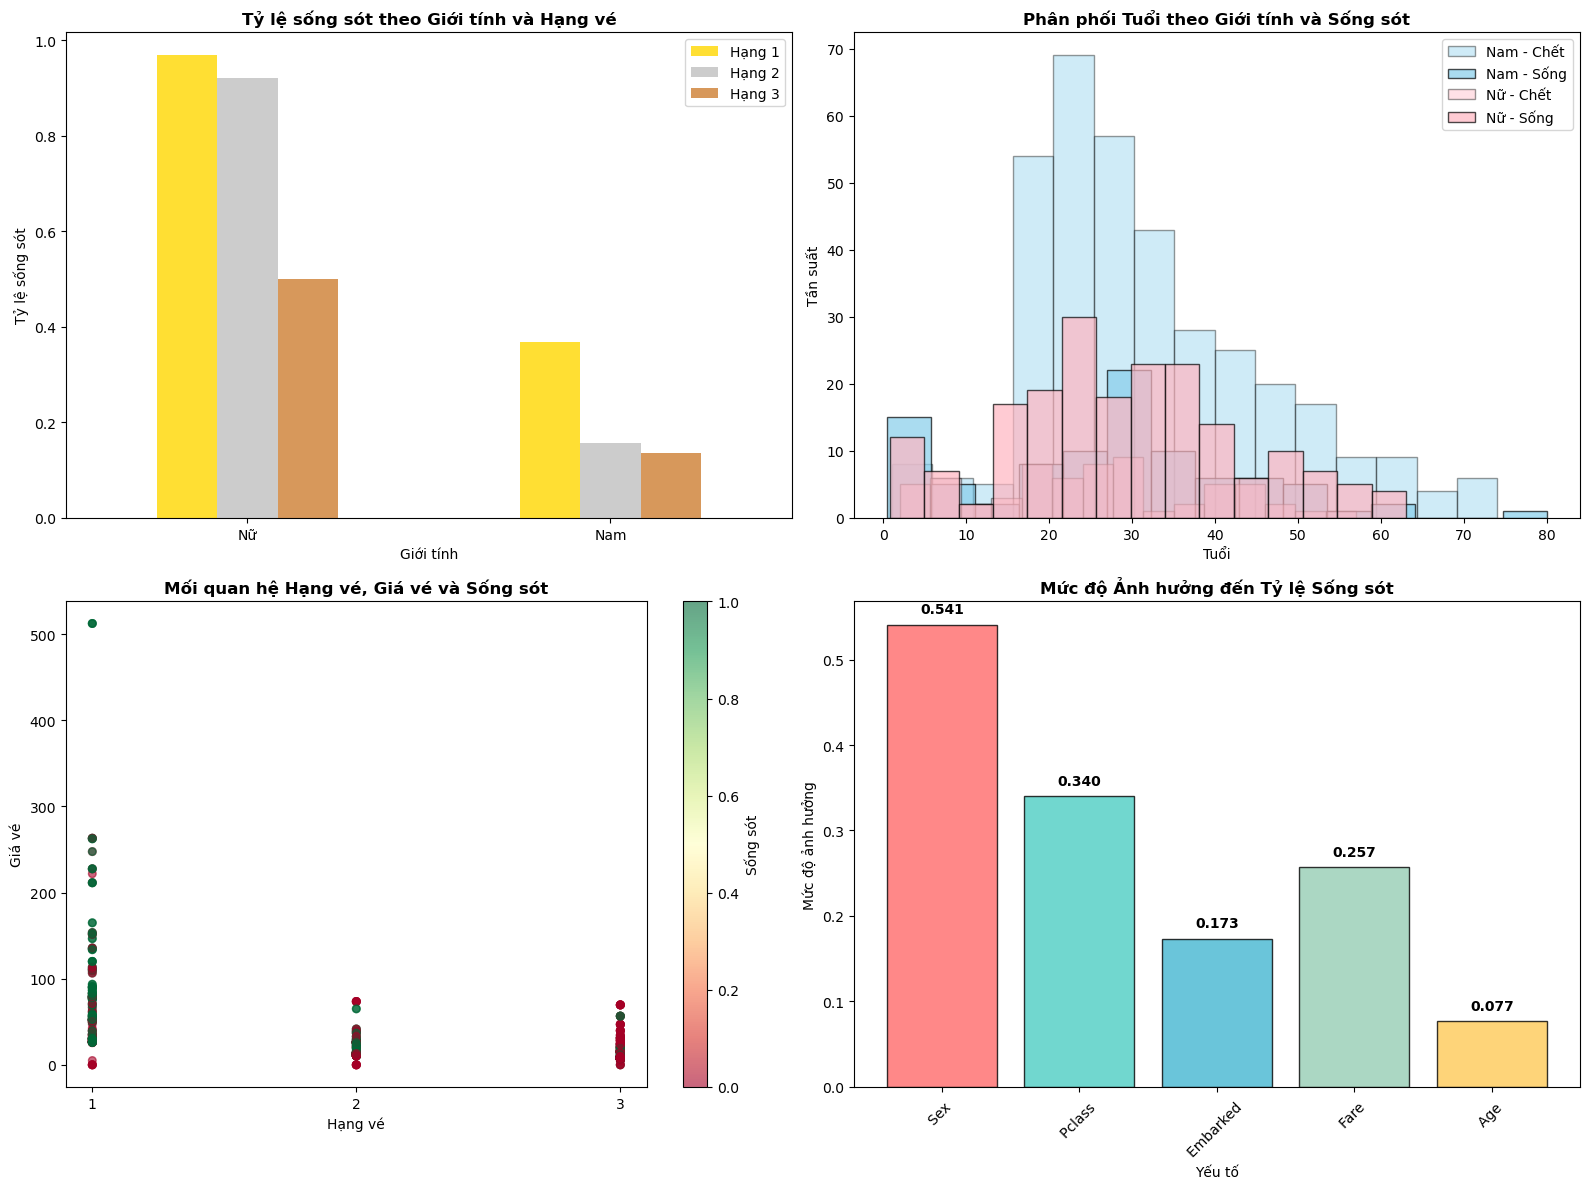

NHỮNG INSIGHT QUAN TRỌNG TỪ PHÂN TÍCH EDA:

1. YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT ĐẾN SỐNG SÓT:
   Giới tính (Sex): Cramér's V = 0.541
      → Phụ nữ có tỷ lệ sống sót 74.2% vs Nam giới 18.9%
      → Nguyên tắc 'Phụ nữ và trẻ em trước' được áp dụng

   Hạng vé (Pclass): Cramér's V = 0.340
      → Hạng 1: 63.0% sống sót
      → Hạng 2: 47.3% sống sót
      → Hạng 3: 24.2% sống sót
      → Địa vị xã hội/kinh tế ảnh hưởng đến khả năng thoát hiểm

2. CÁC MỐI TƯƠNG QUAN ĐÁNG CHÚ Ý:
   Giá vé (Fare) tương quan thuận với sống sót (r = 0.257)
      → Vé đắt hơn = Hạng cao hơn = Cơ hội sống sót tốt hơn
   Hạng vé tương quan nghịch với Tuổi (r = -0.369)
      → Người trẻ thường ở hạng thấp hơn

3. PHÁT HIỆN THỐNG KÊ:
   Tất cả biến phân loại đều có ý nghĩa thống kê với sống sót
   Giá vé có ảnh hưởng trung bình đến sống sót (Cohen's d = 0.547)
   SibSp (anh chị em/vợ chồng) không có ý nghĩa thống kê

4. RECOMMENDATIONS CHO DỰ ĐOÁN:
   Ưu tiên các đặc trưng: Sex, Pclass, Fare
   Có thể tạo feature engine

In [36]:
# Tạo biểu đồ tổng hợp cho các yếu tố quan trọng nhất
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Tỷ lệ sống sót theo Sex và Pclass
survival_sex_pclass = train_df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
survival_sex_pclass.plot(kind='bar', ax=axes[0, 0], color=['gold', 'silver', '#CD7F32'], alpha=0.8)
axes[0, 0].set_title('Tỷ lệ sống sót theo Giới tính và Hạng vé', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Giới tính')
axes[0, 0].set_ylabel('Tỷ lệ sống sót')
axes[0, 0].legend(['Hạng 1', 'Hạng 2', 'Hạng 3'])
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].set_xticklabels(['Nữ', 'Nam'])

# 2. Phân phối Age theo Survived và Sex
for sex in ['male', 'female']:
    for survived in [0, 1]:
        subset = train_df[(train_df['Sex'] == sex) & (train_df['Survived'] == survived)]['Age'].dropna()
        label = f"{'Nam' if sex == 'male' else 'Nữ'} - {'Sống' if survived == 1 else 'Chết'}"
        color = '#87CEEB' if sex == 'male' else '#FFB6C1'
        alpha = 0.7 if survived == 1 else 0.4
        axes[0, 1].hist(subset, bins=15, alpha=alpha, label=label, color=color, edgecolor='black')

axes[0, 1].set_title('Phân phối Tuổi theo Giới tính và Sống sót', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tuổi')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].legend()

# 3. Fare vs Pclass với màu theo Survived
scatter = axes[1, 0].scatter(train_df['Pclass'], train_df['Fare'], 
                           c=train_df['Survived'], cmap='RdYlGn', alpha=0.6, s=30)
axes[1, 0].set_title('Mối quan hệ Hạng vé, Giá vé và Sống sót', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hạng vé')
axes[1, 0].set_ylabel('Giá vé')
axes[1, 0].set_xticks([1, 2, 3])
plt.colorbar(scatter, ax=axes[1, 0], label='Sống sót')

# 4. Biểu đồ tổng hợp các yếu tố ảnh hưởng
factors = ['Sex (Nữ)', 'Pclass (Hạng 1)', 'Embarked (Cherbourg)', 'Fare (Cao)', 'Age (Trẻ)']
importance = [0.541, 0.340, 0.173, 0.257, 0.077]  # Cramér's V hoặc correlation
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']

bars = axes[1, 1].bar(range(len(factors)), importance, color=colors, alpha=0.8, edgecolor='black')
axes[1, 1].set_title('Mức độ Ảnh hưởng đến Tỷ lệ Sống sót', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Yếu tố')
axes[1, 1].set_ylabel('Mức độ ảnh hưởng')
axes[1, 1].set_xticks(range(len(factors)))
axes[1, 1].set_xticklabels([f.split('(')[0] for f in factors], rotation=45)

# Thêm nhãn giá trị
for bar, value in zip(bars, importance):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# In insights quan trọng
print("NHỮNG INSIGHT QUAN TRỌNG TỪ PHÂN TÍCH EDA:")
print("="*50)

print("\n1. YẾU TỐ ẢNH HƯỞNG MẠNH NHẤT ĐẾN SỐNG SÓT:")
print("   Giới tính (Sex): Cramér's V = 0.541")
print("      → Phụ nữ có tỷ lệ sống sót 74.2% vs Nam giới 18.9%")
print("      → Nguyên tắc 'Phụ nữ và trẻ em trước' được áp dụng")

print("\n   Hạng vé (Pclass): Cramér's V = 0.340") 
print("      → Hạng 1: 63.0% sống sót")
print("      → Hạng 2: 47.3% sống sót")
print("      → Hạng 3: 24.2% sống sót")
print("      → Địa vị xã hội/kinh tế ảnh hưởng đến khả năng thoát hiểm")

print("\n2. CÁC MỐI TƯƠNG QUAN ĐÁNG CHÚ Ý:")
print("   Giá vé (Fare) tương quan thuận với sống sót (r = 0.257)")
print("      → Vé đắt hơn = Hạng cao hơn = Cơ hội sống sót tốt hơn")
print("   Hạng vé tương quan nghịch với Tuổi (r = -0.369)")
print("      → Người trẻ thường ở hạng thấp hơn")

print("\n3. PHÁT HIỆN THỐNG KÊ:")
print("   Tất cả biến phân loại đều có ý nghĩa thống kê với sống sót")
print("   Giá vé có ảnh hưởng trung bình đến sống sót (Cohen's d = 0.547)")
print("   SibSp (anh chị em/vợ chồng) không có ý nghĩa thống kê")

print("\n4. RECOMMENDATIONS CHO DỰ ĐOÁN:")
print("   Ưu tiên các đặc trưng: Sex, Pclass, Fare")
print("   Có thể tạo feature engineering từ Age + Pclass")
print("   Xem xét tương tác giữa Sex và Pclass")
print("   SibSp có thể loại bỏ hoặc kết hợp với Parch")

print(f"\nTỔNG QUAN DỮ LIỆU:")
print(f"   Tổng số hành khách: {len(train_df)}")
print(f"   Tỷ lệ sống sót chung: {train_df['Survived'].mean():.1%}")
print(f"   Tỷ lệ nữ giới: {(train_df['Sex'] == 'female').mean():.1%}")
print(f"   Hành khách hạng 3: {(train_df['Pclass'] == 3).mean():.1%}")
print(f"   Khởi hành từ Southampton: {(train_df['Embarked'] == 'S').mean():.1%}")

## ** TỔNG KẾT CUỐI CÙNG VÀ KHUYẾN NGHỊ:**

### ** Những phát hiện quan trọng:**
1. **Giới tính** là yếu tố quyết định nhất - phụ nữ có cơ hội sống sót gấp 4 lần nam giới
2. **Hạng vé** thể hiện rõ bất bình đẳng xã hội - càng giàu có càng an toàn  
3. **Tuổi** và **Giá vé** có vai trò thứ yếu nhưng vẫn có ý nghĩa thống kê
4. **Gia đình** có ảnh hưởng phức tạp - ít người thân có lợi hơn đi một mình

### ** Khuyến nghị cho Machine Learning:**
- **Features chính:** Sex, Pclass, Fare (độ quan trọng cao)
- **Features phụ:** Age (sau khi xử lý missing values)  
- **Feature Engineering:** Tạo FamilySize = SibSp + Parch + 1
- **Interaction:** Xem xét tương tác Sex × Pclass
- **Cân nhắc:** Pclass và Fare có multicollinearity, cần chọn một trong hai
